In [15]:
import pandas as pd #importing the pandas library to work with dataframes

df=pd.read_csv('StudentPerformanceFactors.csv') #reading the csv file and storing it in a dataframe called df

print('Printing the first 5 rows of the dataframe to get an overview of the data:\n')
print(df.head()) 

Printing the first 5 rows of the dataframe to get an overview of the data:

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet

In [41]:
print('df.describe(): getting a statistical summary of the dataframe to understand the distribution of the data:\n')
print(df.describe()) 

print('\nNow that we have an overview of the data, we can start by cleaning it.')


df.isnull() #checking for missing values in the dataframe to identify any potential issues with the data
df.isnull().sum() #counting the number of missing values in each column
print('\ndf_clean=df.dropna(): removing rows with missing values to create a clean dataframe for analysis.\n')
df_clean = df.dropna() 
print('df_clean.isnull().sum(): verifying that there are no missing values in the clean dataframe:\n')
print(df_clean.isnull().sum()) 

df.describe(): getting a statistical summary of the dataframe to understand the distribution of the data:

       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            1.493719           2.967610    67.235659  
std             1.230570           1.031231     3.890456  
min             0.000000           0.000000    55.000

Now that we have a clean dataframe, we can start analyzing the data to find insights about the factors that influence exam scores.

Creating a bar plot to visualize the relationship between tutoring sessions and exam scores:



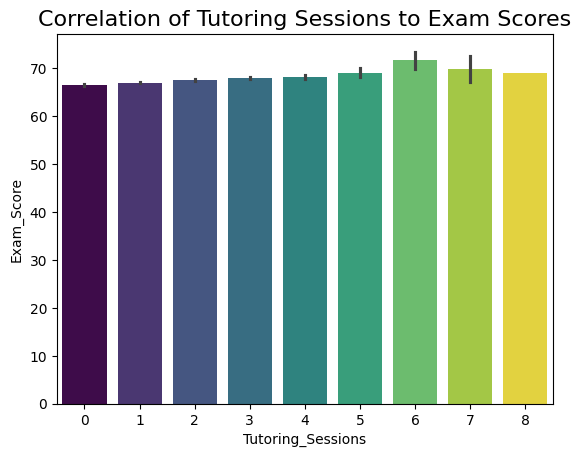

We see our columns are similar in height, so tutoring sessions do not seem to have a significant impact on exam scores.



In [42]:
print('Now that we have a clean dataframe, we can start analyzing the data to find insights about the factors that influence exam scores.\n')

import matplotlib.pyplot as plt #importing the matplotlib library to create visualizations of the data
import seaborn as sns #importing the seaborn library to create more advanced visualizations of the data
sns.barplot(data=df, x='Tutoring_Sessions', y='Exam_Score', palette='viridis', hue='Tutoring_Sessions',legend=False) #creating a bar plot to visualize the relationship between tutoring sessions and exam scores
print('Creating a bar plot to visualize the relationship between tutoring sessions and exam scores:\n')
plt.title('Correlation of Tutoring Sessions to Exam Scores', fontsize=16) #adding a title to the plot
plt.show()
print('We see our columns are similar in height, so tutoring sessions do not seem to have a significant impact on exam scores.\n')

In [18]:
print('Instead of creating 20 different bar plots for each factor, we can create a sorted correlation series of the most important factors:\n')

print('a) numerical variables:\n ')

#creating a correlation series for the numerical variables with respect to exam scores
num_corr_list = df.corr(numeric_only=True)['Exam_Score'].sort_values(ascending=False)
num_corr_list = num_corr_list.drop('Exam_Score') #dropping the Exam_Score column from the correlation results to focus on the other factors

print(num_corr_list)

print('\nWe can see that the most positively correlated numerical factor with exam scores is Attendance.\n')

print('b) categorical variables:\n')

#creating a list of categorical columns:
cat_columns = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
#converting categorical variables into dummy/indicator variables to calculate correlations with the exam scores:
df_temp = pd.get_dummies(df[cat_columns+['Exam_Score']], columns=cat_columns)
#creating a correlation series for the categorical variables with respect to exam scores
cat_corr_list = df_temp.corr()['Exam_Score'].sort_values(ascending=False)
cat_corr_list = cat_corr_list.drop('Exam_Score')

#we now have a list of the correlation values for each categorical value type, 
#e.g. Access_To_Resources_Yes, Access_To_Resources_No, etc. 

#we can can calculate the "gap" for each categorical factor to get the total swing

cat_gaps={}

for col in cat_columns:
    # finding all dummy columns related to each category (e.g., all starting with 'Parental_Involvement_')
    related_dummies = [c for c in cat_corr_list.index if c.startswith(col + '_')]
    
    if related_dummies:
        #gettimg the correlation values for these dummies:
        vals = cat_corr_list[related_dummies]
        #the "gap" is the difference between the best impact and the worst impact:
        gap = vals.max()-vals.min()
        cat_gaps[col]=gap

gap_series = pd.Series(cat_gaps).sort_values(ascending=False)

print(gap_series)

print('\nWe can see that the most positively correlated categorical factor with exam scores is Access To Resources.\n')

Instead of creating 20 different bar plots for each factor, we can create a sorted correlation series of the most important factors:

a) numerical variables:
 
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64

We can see that the most positively correlated numerical factor with exam scores is Attendance.

b) categorical variables:

Access_to_Resources           0.275920
Parental_Involvement          0.253998
Parental_Education_Level      0.179582
Learning_Disabilities         0.170132
Peer_Influence                0.169774
Family_Income                 0.158071
Distance_from_Home            0.151400
Motivation_Level              0.140208
Extracurricular_Activities    0.128763
Teacher_Quality               0.114515
Internet_Access               0.102950
School_Type                   0.017687
Gender                        0.00


Lets create a graph to visualize the top 10 drivers of student success based on the correlation values we calculated:



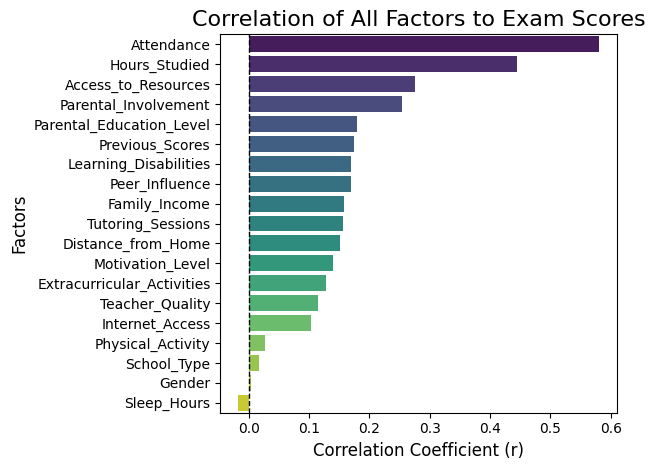

Finally, we have a clear visualization of the top drivers of student success based on their correlation with exam scores.
We can see that Attendance and Access To Resources are the most influential factors, while Sleep Hours and School Type has a much smaller impact on exam scores.



In [39]:
print('\nLets create a graph to visualize the top 10 drivers of student success based on the correlation values we calculated:\n')

#creating a "master list" of all the factors sorted by their correlation values to exam scores
master_list = pd.concat([num_corr_list, gap_series]).sort_values(ascending=False)

sns.barplot(x=master_list.values, y=master_list.index, palette='viridis', hue=master_list.index, legend=False)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

#adding labels and title
plt.title('Correlation of All Factors to Exam Scores', fontsize=16)
plt.xlabel('Correlation Coefficient (r)', fontsize=12)
plt.ylabel('Factors', fontsize=12)

#cleaning up the layout
plt.tight_layout()
plt.show()

print('Finally, we have a clear visualization of the top drivers of student success based on their correlation with exam scores.\nWe can see that Attendance and Access To Resources are the most influential factors, while Sleep Hours and School Type has a much smaller impact on exam scores.\n')
